In [23]:
import numpy as np 
import torch

seed = 13202050 # replace with your student ID
np.random.seed(seed) 
torch.manual_seed(seed)

f = lambda x: torch.sin(torch.exp(x[:,0])+ x[:,1])

train_input = torch.zeros(1000, 2) # 1000 samples, 2 variables
train_ranges = np.array([0, 0.5] * 2).reshape(2, 2)

test_input = torch.zeros(1000, 2)
test_ranges = np.array([0.5, 1] * 2).reshape(2, 2)

for i in range(2):
    train_input[:, i] = ( 
        torch.rand( 
            1000 , 
        )
        * (train_ranges[i, 1] - train_ranges[i, 0]) 
        + train_ranges[i, 0]
    )   
    test_input[:, i] = (
        torch.rand(
            1000 , 
        )
        * (test_ranges[i, 1] - test_ranges[i, 0]) 
        + test_ranges[i, 0]
    )
train_label = f(train_input)
test_label = f(test_input)

In [2]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np

np.random.seed(42)


def square_loss(targets, predictions):
    loss = 0
    for t, p in zip(targets, predictions):
        loss += (t - p) ** 2
    loss = loss / len(targets)
    return 0.5 * loss

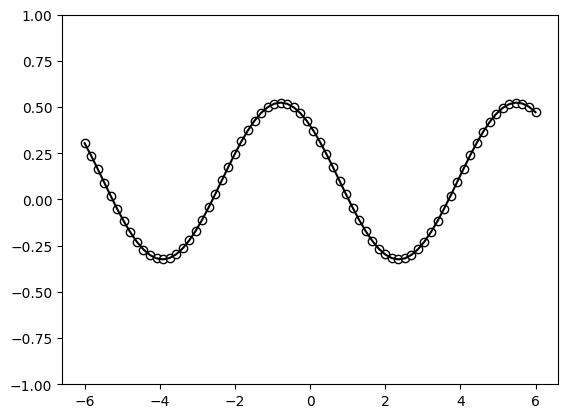

In [3]:
degree = 1  # degree of the target function
scaling = 1  # scaling of the data
coeffs = [0.15 + 0.15j] * degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency


def target_function(x):
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = coeff0
    for idx, coeff in enumerate(coeffs):
        exponent = np.complex128(scaling * (idx + 1) * x * 1j)
        conj_coeff = np.conjugate(coeff)
        res += coeff * np.exp(exponent) + conj_coeff * np.exp(-exponent)
    return np.real(res)
x = np.linspace(-6, 6, 70, requires_grad=False)
target_y = np.array([target_function(x_) for x_ in x], requires_grad=False)

plt.plot(x, target_y, c="black")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()

In [6]:
scaling = 1

dev = qml.device("default.qubit", wires=1)


def S(x):
    """Data-encoding circuit block."""
    qml.RX(scaling * x, wires=0)


def W(theta):
    """Trainable circuit block."""
    qml.Rot(theta[0], theta[1], theta[2], wires=0)


@qml.qnode(dev)
def serial_quantum_model(weights, x):

    for theta in weights[:-1]:
        W(theta)
        S(x)

    # (L+1)'th unitary
    W(weights[-1])

    return qml.expval(qml.PauliZ(wires=0))

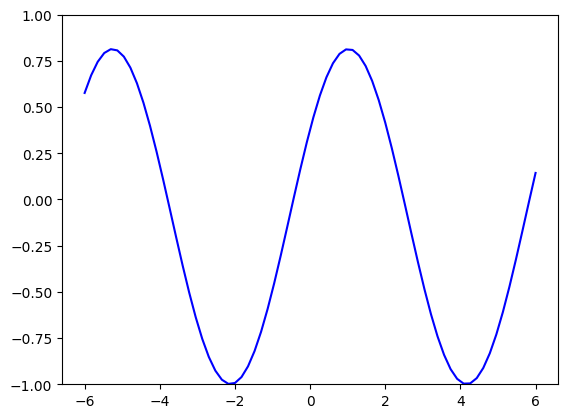

In [13]:
r = 1  # number of times the encoding gets repeated (here equal to the number of layers)
weights = (
    2 * np.pi * np.random.random(size=(r + 1, 3), requires_grad=True)
)  # some random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [serial_quantum_model(weights, x_) for x_ in x]

plt.plot(x, random_quantum_model_y, c="blue")
plt.ylim(-1, 1)
plt.show()

In [14]:
def cost(weights, x, y):
    predictions = [serial_quantum_model(weights, x_) for x_ in x]
    return square_loss(y, predictions)


max_steps = 50
opt = qml.AdamOptimizer(0.3)
batch_size = 25
cst = [cost(weights, x, target_y)]  # initial cost

for step in range(max_steps):

    # Select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # Update the weights by one optimizer step
    weights, _, _ = opt.step(cost, weights, x_batch, y_batch)

    # Save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cst.append(c)
    if (step + 1) % 10 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step  10: 0.056914975850408875
Cost at step  20: 0.00499700878513741
Cost at step  30: 0.003016357329812082
Cost at step  40: 0.0015726420385149523
Cost at step  50: 0.0008376511845132022


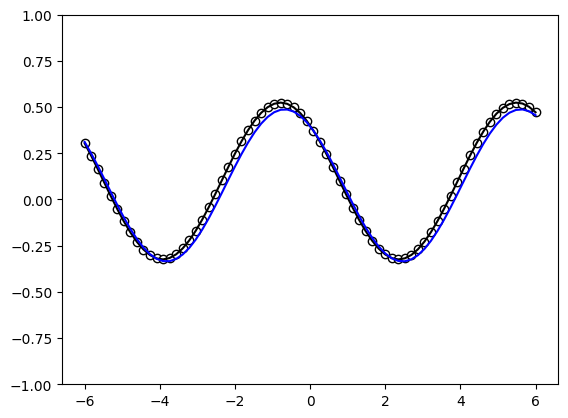

In [15]:
predictions = [serial_quantum_model(weights, x_) for x_ in x]

plt.plot(x, target_y, c="black")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.plot(x, predictions, c="blue")
plt.ylim(-1, 1)
plt.show()

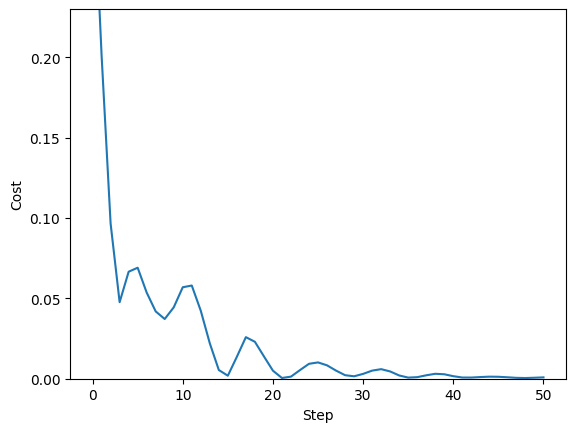

In [16]:
plt.plot(range(len(cst)), cst)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.ylim(0, 0.23)
plt.show()

In [35]:
import numpy as np 
import torch
import matplotlib.pyplot as plt

seed = 13202050
np.random.seed(seed) 
torch.manual_seed(seed)

f = lambda x: torch.sin(torch.exp(x[:,0]) + x[:,1])

train_input = torch.zeros(1000, 2)
test_input  = torch.zeros(1000, 2)


train_ranges = torch.tensor([[0, 0.5], [0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1], [0.5, 1]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(1000)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(1000)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

In [36]:

def S(x):
    """2D Data-encoding"""
    qml.RX(scaling * x[0], wires=0)  # encode x1
    qml.RY(scaling * x[1], wires=0)  # encode x2
@qml.qnode(dev)
def serial_quantum_model(weights, x):

    for theta in weights[:-1]:
        W(theta)
        S(x)   # 現在 x 是 vector

    W(weights[-1])

    return qml.expval(qml.PauliZ(wires=0))
x_train = train_input.detach().numpy()   # shape = (1000, 2)
y_train = train_label.detach().numpy()
def loss_fn(weights, x, y):
    preds = np.array([serial_quantum_model(weights, x_) for x_ in x])
    preds = np.real(preds)
    return np.mean((preds - y) ** 2)
###########
opt = qml.GradientDescentOptimizer(stepsize=0.1)

steps = 100
loss_history = []

for step in range(steps):
    
    weights, loss = opt.step_and_cost(
        lambda w: loss_fn(w, x_train, y_train),
        weights
    )
    
    loss_history.append(loss)
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss}")

ValueError: setting an array element with a sequence.

layers = 1
qubits = 1



Step 0: Loss = 2.7506607715135742
Step 10: Loss = 0.01042874030237009
Step 20: Loss = 0.00979812828121665
Step 30: Loss = 0.023821399504385433
Step 40: Loss = 0.010892524366138906
Step 50: Loss = 0.0019134650486435953
Step 60: Loss = 0.0009769699489246433
Step 70: Loss = 0.0007548629217764873
Step 80: Loss = 0.0006938569965185317
Step 90: Loss = 0.0006825046293205976


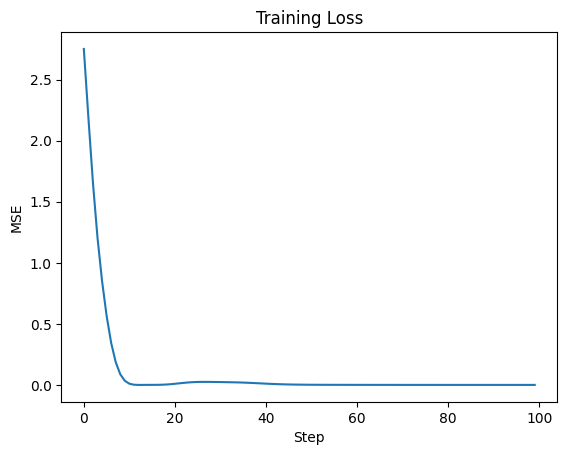

Test Loss: 0.38602069901954783
Train MSE: 0.0006808215615529953
Test  MSE: 0.38602069901954783


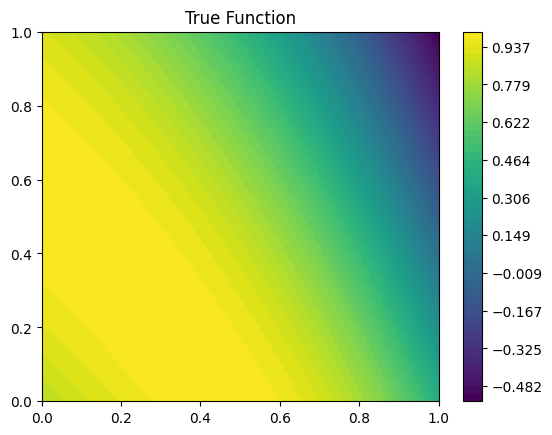

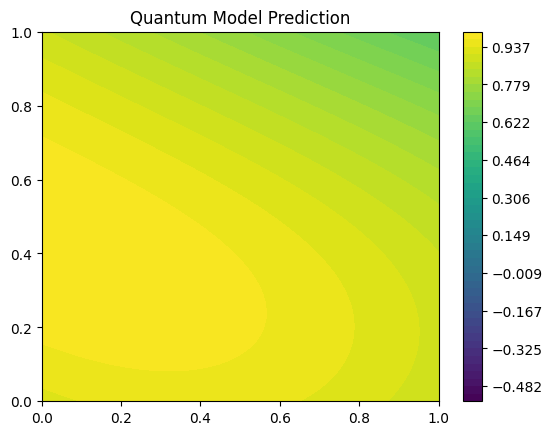

In [9]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=1)
scaling = 1

def S(x):
    # 2D encoding
    qml.RX(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=0)

def W(theta):
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 1  # try 1, 3, 5 to see expressivity difference
weights = torch.randn((r+1, 3), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


layer = 3 qubit =1


Step 0: Loss = 0.810183771144963
Step 10: Loss = 0.08312383484005127
Step 20: Loss = 0.019300802278675425
Step 30: Loss = 0.01083074749060345
Step 40: Loss = 0.007842867615549103
Step 50: Loss = 0.006778142473222063
Step 60: Loss = 0.005985577335344885
Step 70: Loss = 0.0050883931937932714
Step 80: Loss = 0.0040792889855762356
Step 90: Loss = 0.0030294625071062907


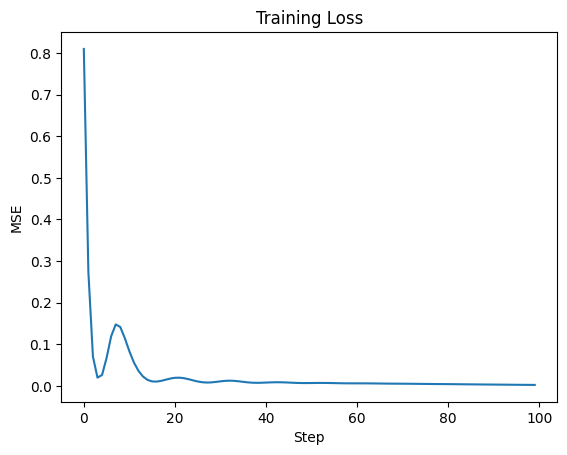

Test Loss: 0.04170502447116429
Train MSE: 0.002099380551147092
Test  MSE: 0.04170502447116429


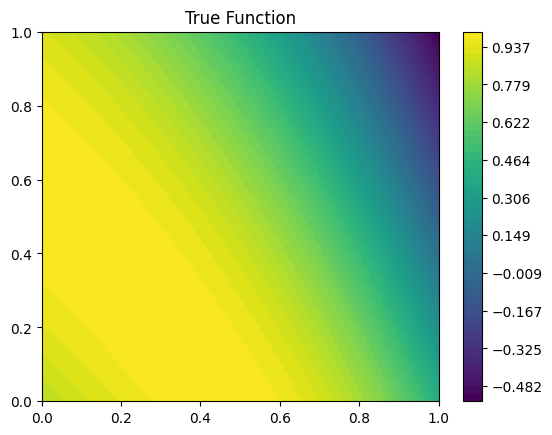

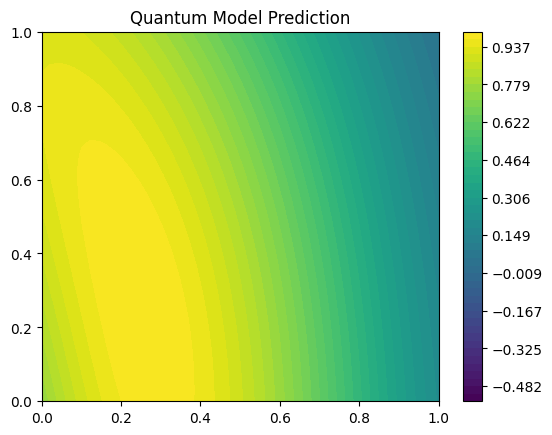

In [10]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=1)
scaling = 1

def S(x):
    # 2D encoding
    qml.RX(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=0)

def W(theta):
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 3  # try 1, 3, 5 to see expressivity difference
weights = torch.randn((r+1, 3), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


layer = 5 qubit = 1


Step 0: Loss = 1.0641349891659797
Step 10: Loss = 0.013418215563231353
Step 20: Loss = 0.006081369452679567
Step 30: Loss = 0.006256899536211773
Step 40: Loss = 0.003257848343938716
Step 50: Loss = 0.0015523270182693906
Step 60: Loss = 0.000784460333379915
Step 70: Loss = 0.0004701089444273273
Step 80: Loss = 0.00033407162455905114
Step 90: Loss = 0.00025775066550146985


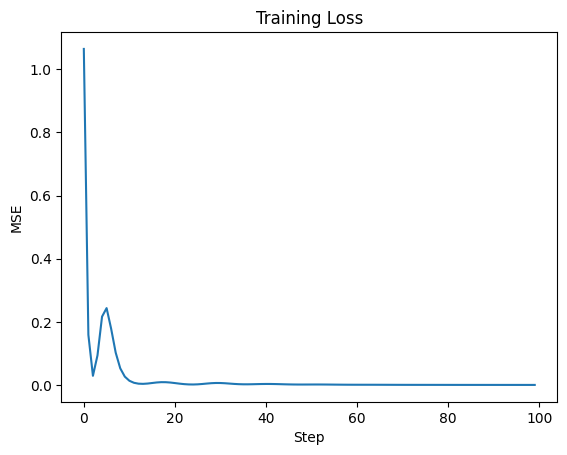

Test Loss: 0.06328190658346758
Train MSE: 0.00021948358196095715
Test  MSE: 0.06328190658346758


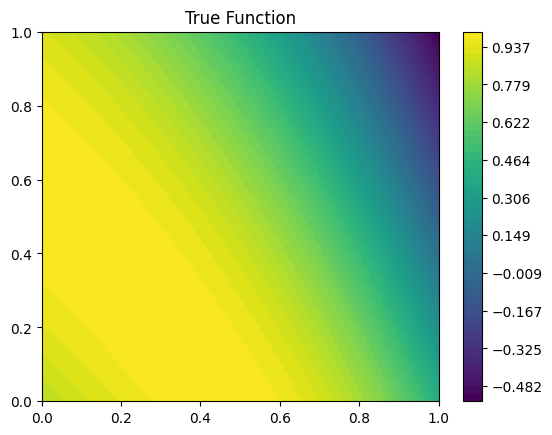

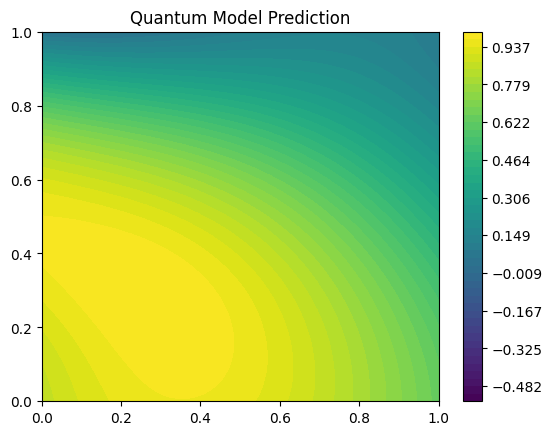

In [11]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=1)
scaling = 1

def S(x):
    # 2D encoding
    qml.RX(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=0)

def W(theta):
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 5  # try 1, 3, 5 to see expressivity difference
weights = torch.randn((r+1, 3), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


layer = 1 qubit = 2


Step 0: Loss = 0.5666031875283475
Step 10: Loss = 0.014731663538972976
Step 20: Loss = 0.0042411924837357
Step 30: Loss = 0.0016052764396984297
Step 40: Loss = 0.0012258769429181564
Step 50: Loss = 0.0009678465504672178
Step 60: Loss = 0.0007880797606523842
Step 70: Loss = 0.0006595932023768488
Step 80: Loss = 0.0006430112511596348
Step 90: Loss = 0.0006380778652571186


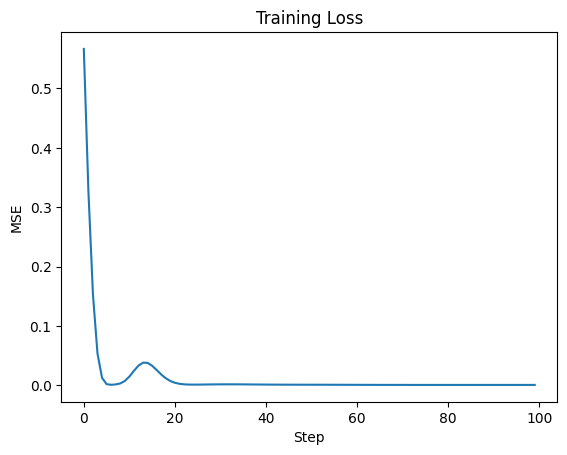

Test Loss: 0.12189397166586914
Train MSE: 0.0006346604255666428
Test  MSE: 0.12189397166586914


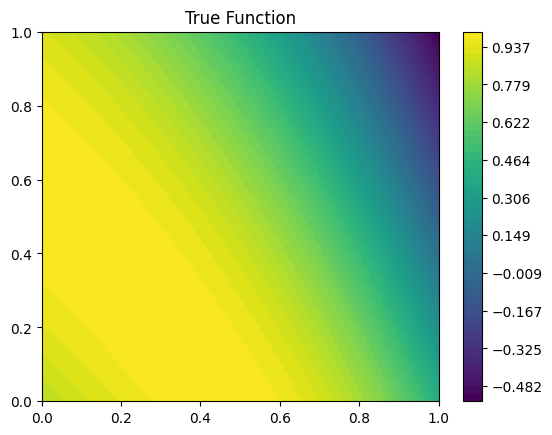

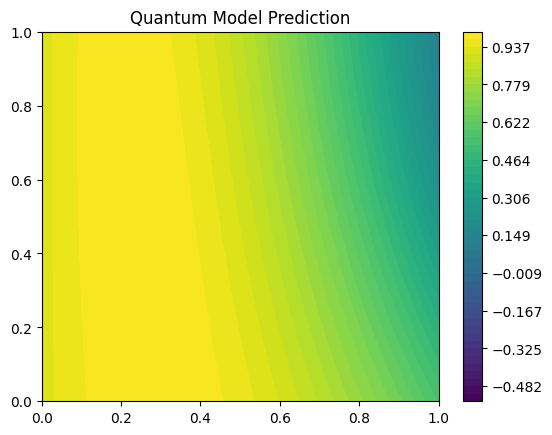

In [6]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=2)
scaling = 1

def S(x):
    qml.RY(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=1)

    qml.RZ(scaling * x[0], wires=0)
    qml.RZ(scaling * x[1], wires=1)

    qml.CNOT(wires=[0, 1])
    qml.RZ(scaling * x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])


def W(theta):
    qml.Rot(theta[0, 0], theta[1, 0], theta[2, 0], wires=0)
    qml.Rot(theta[0, 1], theta[1, 1], theta[2, 1], wires=1)
    qml.CZ(wires=[0, 1])
@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 1  
weights = torch.randn((r+1, 3, 2), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


Step 0: Loss = 2.1208235076414286
Step 10: Loss = 0.1108464514401329
Step 20: Loss = 0.005480068816315911
Step 30: Loss = 0.01141488394334405
Step 40: Loss = 0.0006347343245475716
Step 50: Loss = 0.00045776482025822055
Step 60: Loss = 0.00018984362526852067
Step 70: Loss = 9.99755114977133e-05
Step 80: Loss = 5.9131117981971944e-05
Step 90: Loss = 4.569588077252539e-05


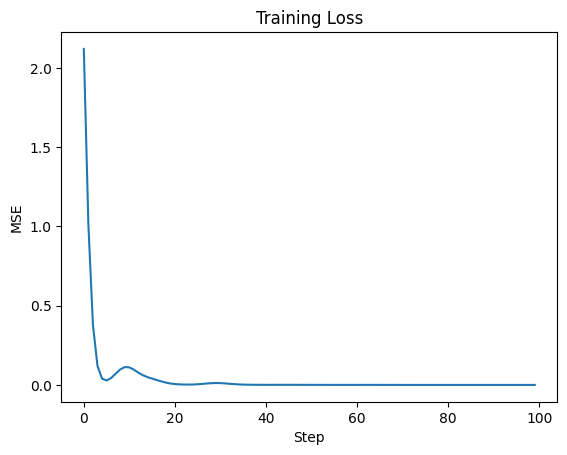

Test Loss: 0.07507568877835478
Train MSE: 4.3390894023476326e-05
Test  MSE: 0.07507568877835478


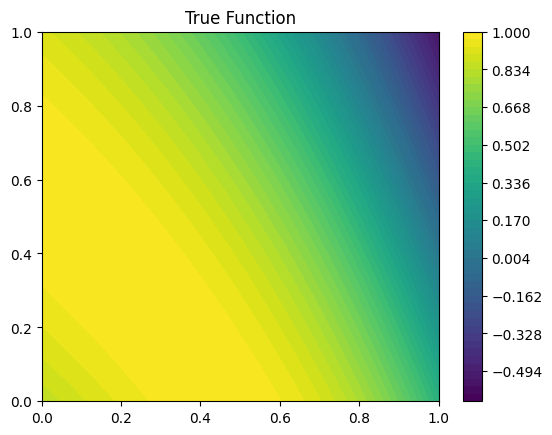

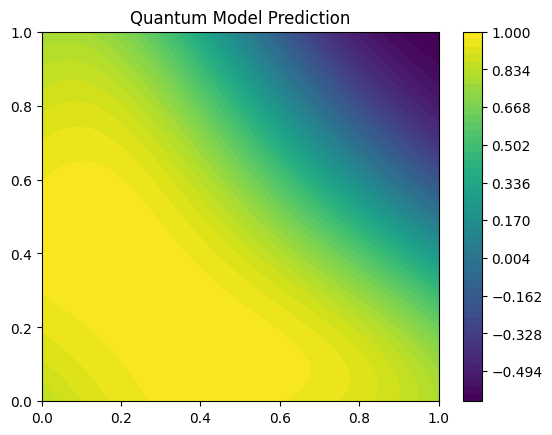

In [8]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=2)
scaling = 1

def S(x):
    qml.RY(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=1)

    qml.RZ(scaling * x[0], wires=0)
    qml.RZ(scaling * x[1], wires=1)

    qml.CNOT(wires=[0, 1])
    qml.RZ(scaling * x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])


def W(theta):
    qml.Rot(theta[0, 0], theta[1, 0], theta[2, 0], wires=0)
    qml.Rot(theta[0, 1], theta[1, 1], theta[2, 1], wires=1)
    qml.CZ(wires=[0, 1])
@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 3 
weights = torch.randn((r+1, 3, 2), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


Step 0: Loss = 0.880464051479506
Step 10: Loss = 0.05006946699677397
Step 20: Loss = 0.00472710328973111
Step 30: Loss = 0.003690388853975106
Step 40: Loss = 0.0015771444607200044
Step 50: Loss = 0.0009017857674189307
Step 60: Loss = 0.0007192586071109976
Step 70: Loss = 0.0005772099440003318
Step 80: Loss = 0.00041641797468378093
Step 90: Loss = 0.00028001510589615783


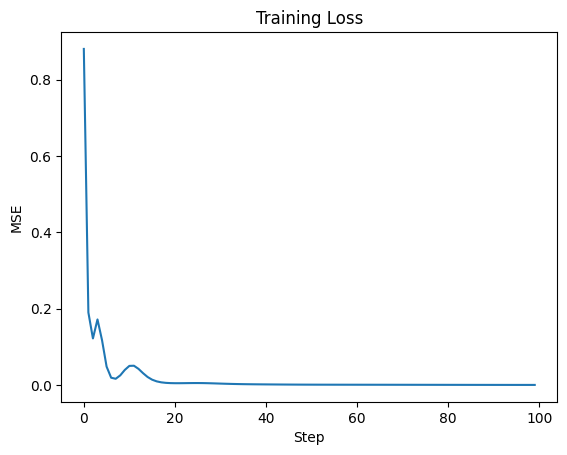

Test Loss: 0.21253662721975997
Train MSE: 0.00021195091571870928
Test  MSE: 0.21253662721975997


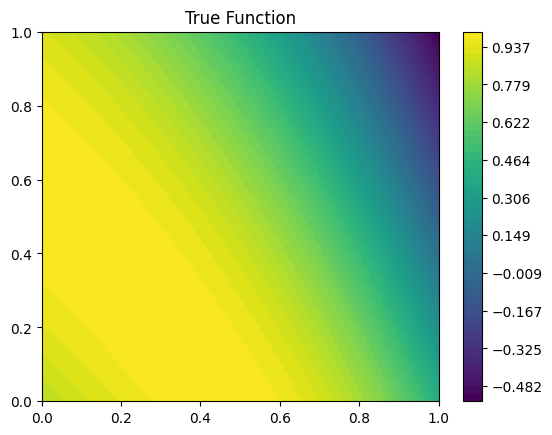

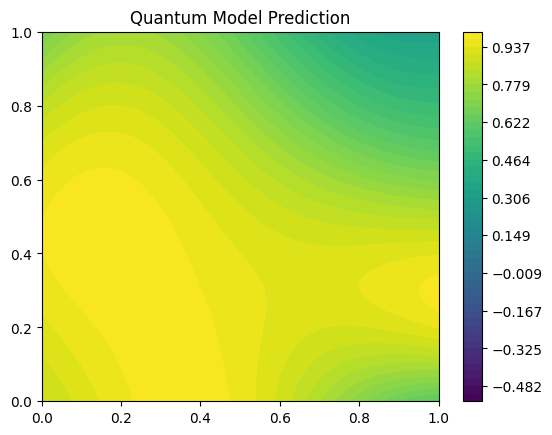

In [10]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=2)
scaling = 1

def S(x):
    qml.RY(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=1)

    qml.RZ(scaling * x[0], wires=0)
    qml.RZ(scaling * x[1], wires=1)

    qml.CNOT(wires=[0, 1])
    qml.RZ(scaling * x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])


def W(theta):
    qml.Rot(theta[0, 0], theta[1, 0], theta[2, 0], wires=0)
    qml.Rot(theta[0, 1], theta[1, 1], theta[2, 1], wires=1)
    qml.CZ(wires=[0, 1])
@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 5
weights = torch.randn((r+1, 3, 2), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()
